# 04 – Model 2: DeBERTa-v3 NER Pipeline
Supervised token classification fine-tuned on the unified dataset.


In [15]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import json
from pathlib import Path
from src.utils.io import load_json, load_jsonl
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Source Code Walkthrough

The DeBERTa pipeline consists of three source files: tokenization/dataset preparation, training loop, and inference. Below we display the key logic from each.

### dataset.py — Tokenization and label alignment

DeBERTa uses sub-word tokenization (WordPiece). A single word like `"Aaliyah"` may become
`["Aa", "##liy", "##ah"]`. We must align our word-level BIO labels to these sub-tokens:
only the **first** sub-token of each word gets a label; continuation sub-tokens get `-100` (ignored by the loss).

```python
# src/models/ner_deberta/dataset.py

class PIIDataset(Dataset):
    def __getitem__(self, idx):
        tokens = record["tokens"]        # word-level: ["My", "name", "is", "Aaliyah"]
        word_labels = record["labels"]    # BIO labels: ["O",  "O",    "O",  "B-PERSON"]

        # DeBERTa tokenizer splits words → sub-tokens
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,     # tells tokenizer these are pre-split words
            max_length=512,
            truncation=True,
        )

        # Align labels: first sub-token gets the label, rest get -100
        word_ids = encoding.word_ids()    # [None, 0, 1, 2, 3, 3, 3, None]
        label_ids = []
        prev_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)             # [CLS], [SEP], padding
            elif word_idx != prev_word_idx:
                label_ids.append(label2id[word_labels[word_idx]])  # first sub-token
            else:
                label_ids.append(-100)             # continuation sub-token
            prev_word_idx = word_idx

        return {"input_ids": ..., "attention_mask": ..., "labels": label_ids}
```

### train.py — Fine-tuning with HuggingFace Trainer

The training script loads the pre-trained DeBERTa, adds a classification head,
and fine-tunes using the HuggingFace `Trainer` API with early stopping:

```python
# src/models/ner_deberta/train.py

def train(config_path="configs/deberta.yaml"):
    # Load pre-trained model + add token classification head
    model = AutoModelForTokenClassification.from_pretrained(
        "microsoft/deberta-v3-base",
        num_labels=15,           # 7 entity types × 2 (B/I) + O
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    training_args = TrainingArguments(
        num_train_epochs=10,
        per_device_train_batch_size=16,
        gradient_accumulation_steps=2,    # effective batch = 32
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,      # keep the best checkpoint
        metric_for_best_model="f1",
        fp16=True,                        # mixed precision for speed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,  # seqeval F1 per epoch
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()
    trainer.save_model("outputs/checkpoints/deberta/best_model")
```

### predict.py — Inference pipeline

At inference time, we load the saved checkpoint, run each batch through the model,
and map predicted label IDs back to BIO strings:

```python
# src/models/ner_deberta/predict.py

def predict(records, model_dir, batch_size=32):
    # Load saved checkpoint
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForTokenClassification.from_pretrained(model_dir)
    model.to("cuda")
    model.eval()

    # Create DataLoader from test records
    dataset = PIIDataset(records, tokenizer, LABEL2ID, max_length=512)
    loader  = DataLoader(dataset, batch_size=batch_size)

    all_preds = []
    with torch.no_grad():                        # no gradients needed at inference
        for batch in loader:
            outputs = model(
                input_ids=batch["input_ids"].to("cuda"),
                attention_mask=batch["attention_mask"].to("cuda"),
            )
            pred_ids = np.argmax(outputs.logits.cpu().numpy(), axis=2)

            # Map sub-token predictions back to word-level labels
            # (skip -100 positions — same alignment as training)
            for pred_row, label_row in zip(pred_ids, batch["labels"].numpy()):
                seq = [ID2LABEL[int(pid)]
                       for pid, lid in zip(pred_row, label_row)
                       if lid != -100]
                all_preds.append(seq)

    return all_preds
```

In [16]:
# Results pre-computed on BGU cluster (RTX 3090, ~3.5 min inference)
results_path = Path('../outputs/results/ner_results.json')
results = load_json(results_path)
m = results['metrics']
print(f"DeBERTa — Precision: {m['precision']:.4f}  Recall: {m['recall']:.4f}  F1: {m['f1']:.4f}")

DeBERTa — Precision: 0.9877  Recall: 0.9806  F1: 0.9841


## 3. Training curves
*(reads Hugging Face trainer_state.json)*

Using: ../outputs/checkpoints/deberta\checkpoint-9416\trainer_state.json  (step 9416, epoch 8.0)


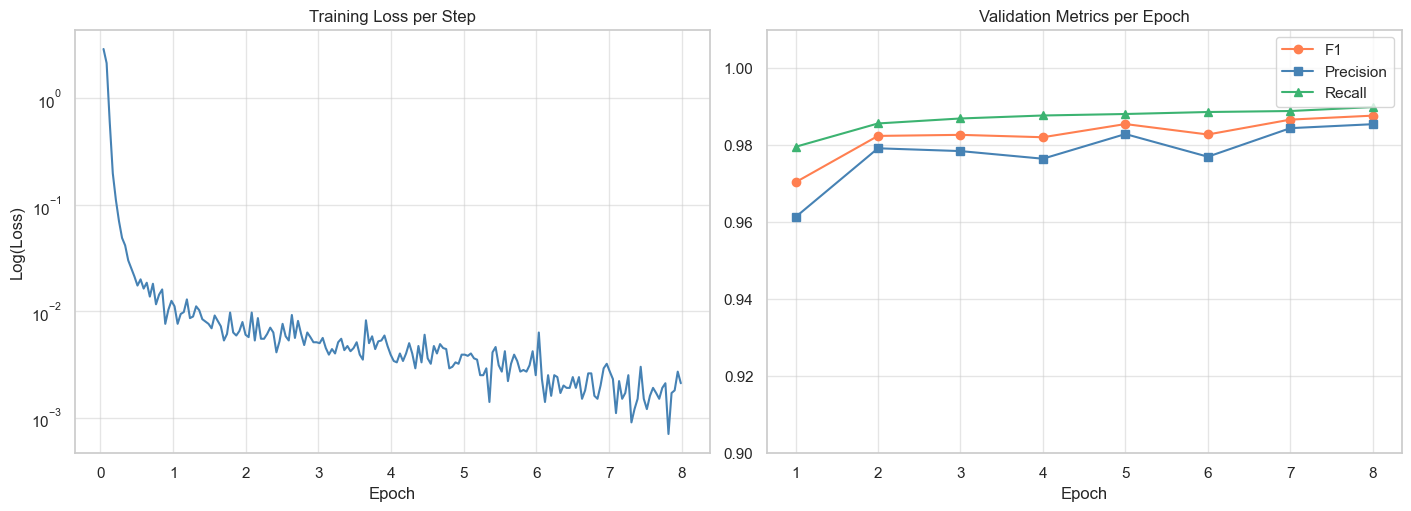


Best validation F1: 0.9877 at epoch 8.0


In [17]:
# Pick the trainer_state with the most steps (latest checkpoint)
state_files = glob.glob('../outputs/checkpoints/deberta/**/trainer_state.json', recursive=True)
state_files = sorted(state_files, key=lambda f: json.load(open(f)).get('global_step', 0), reverse=True)

if state_files:
    state = json.load(open(state_files[0]))
    print(f"Using: {state_files[0]}  (step {state['global_step']}, epoch {state['epoch']})")
    log = state.get('log_history', [])

    train_loss = [(e['epoch'], e['loss'])     for e in log if 'loss' in e and 'eval_loss' not in e]
    eval_rows  = [(e['epoch'], e['eval_f1'],
                   e['eval_precision'], e['eval_recall'])
                  for e in log if 'eval_f1' in e]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # Training loss
    if train_loss:
        xs, ys = zip(*train_loss)
        axes[0].plot(xs, ys, color='steelblue', linewidth=1.5)
        axes[0].set_title('Training Loss per Step')
        axes[0].set_yscale('log')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Log(Loss)')

    # Validation F1, P, R per epoch
    if eval_rows:
        ep, f1, prec, rec = zip(*eval_rows)
        axes[1].plot(ep, f1,   color='coral',      marker='o', label='F1')
        axes[1].plot(ep, prec, color='steelblue',  marker='s', label='Precision')
        axes[1].plot(ep, rec,  color='mediumseagreen', marker='^', label='Recall')
        axes[1].set_title('Validation Metrics per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylim(0.9, 1.01)
        axes[1].legend()

    fig.savefig('../outputs/results/deberta_training_curves.png', dpi=150)
    plt.show()

    print(f"\nBest validation F1: {max(r[1] for r in eval_rows):.4f} at epoch {max(eval_rows, key=lambda r: r[1])[0]}")
else:
    print('No trainer_state.json found.')

## 4. Per-entity F1

,entity,precision,recall,f1,support
2,ID,1.0000,1.0000,1.0000,70
1,EMAIL,0.9946,0.9982,0.9964,1097
3,PERSON,0.9920,0.9831,0.9875,4669
6,USERNAME,1.0000,0.9728,0.9862,184
5,URL,0.9660,0.9900,0.9779,201
4,PHONE,0.9816,0.9638,0.9726,221
0,ADDRESS,0.9716,0.9614,0.9664,1528


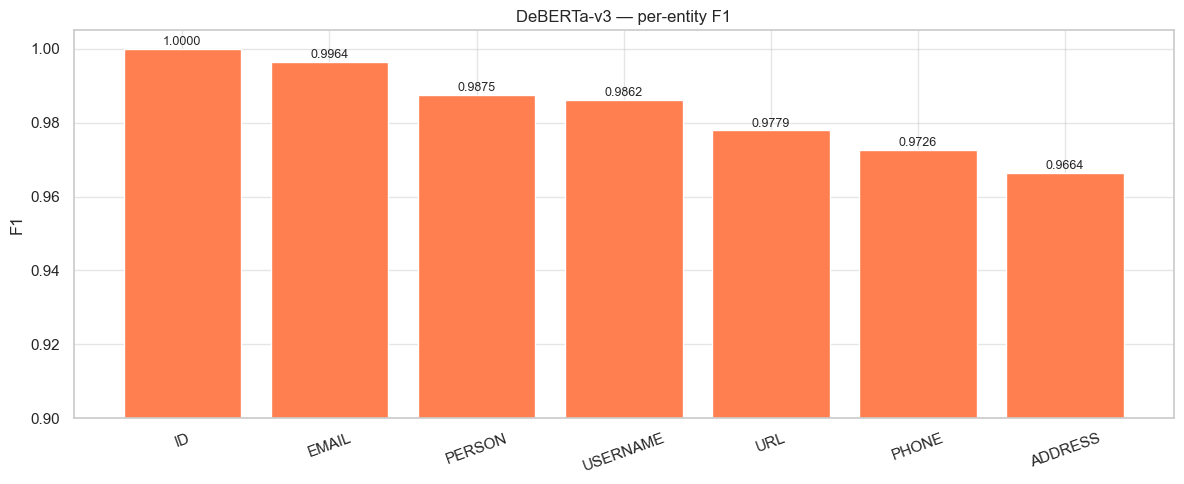

In [18]:
per = results['metrics'].get('per_entity', {})
df  = pd.DataFrame([{'entity': k, **v} for k, v in per.items()]).sort_values('f1', ascending=False)
display(df)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df['entity'], df['f1'], color='coral', edgecolor='white')
ax.set_title('DeBERTa-v3 — per-entity F1')
ax.set_ylim(0.9, 1.005)
ax.set_ylabel('F1')
for bar, val in zip(bars, df['f1']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}', ha='center', fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/results/deberta_per_entity_f1.png', dpi=150)
plt.show()

## 5. Qualitative sample

In [19]:
test_records = load_jsonl('../data/processed/test.jsonl')
preds = results['predictions']

for rec, pred in list(zip(test_records, preds))[:1]:
    true = rec['labels']
    text = ' '.join(rec['tokens'][:25])
    true_ents = [(t, l) for t, l in zip(rec['tokens'], true) if l != 'O']
    pred_ents = [(t, l) for t, l in zip(rec['tokens'], pred) if l != 'O']
    if true_ents or pred_ents:
        print(f'Text: {text} ...')
        print(f'  True: {true_ents[:5]}')
        print(f'  Pred: {pred_ents[:5]}')
        print()

Text: write an email to rose parker dvm at clemmie . carroll @ hotmail . com summarizing the key findings from a recent occupational therapy research ...
  True: [('rose', 'B-PERSON'), ('parker', 'I-PERSON'), ('dvm', 'I-PERSON'), ('clemmie', 'B-EMAIL'), ('.', 'I-EMAIL')]
  Pred: [('rose', 'B-PERSON'), ('parker', 'I-PERSON'), ('dvm', 'I-PERSON'), ('clemmie', 'B-EMAIL'), ('.', 'I-EMAIL')]



## 6. Error Analysis — Where DeBERTa fails

Despite 99% F1, the model does make mistakes. We analyze the 74 records (out of 4,710) with at least one error.

In [20]:
from IPython.display import display, HTML
from src.utils.io import tokens_to_text

# Categorize all errors
false_positives = []   # pred=PII, gt=O (model finds PII that isn't labeled)
false_negatives = []   # gt=PII, pred=O (model misses real PII)
wrong_types = []       # both PII but different type

for rec, pred in zip(test_records, preds):
    gt = rec['labels']
    toks = rec['tokens']
    text = tokens_to_text(toks, rec.get('trailing_whitespace'))

    for i in range(min(len(gt), len(pred))):
        if gt[i].startswith('B-') and pred[i] == 'O':
            etype = gt[i][2:]
            j = i + 1
            while j < len(gt) and gt[j] == f'I-{etype}': j += 1
            false_negatives.append({
                'entity': ' '.join(toks[i:j]), 'type': etype,
                'text': text[:200], 'source': rec.get('source')
            })
        elif pred[i].startswith('B-') and gt[i] == 'O':
            etype = pred[i][2:]
            j = i + 1
            while j < len(pred) and pred[j] == f'I-{etype}': j += 1
            false_positives.append({
                'entity': ' '.join(toks[i:j]), 'type': etype,
                'text': text[:200], 'source': rec.get('source')
            })
        elif gt[i].startswith('B-') and pred[i].startswith('B-') and gt[i] != pred[i]:
            wrong_types.append({
                'entity': toks[i], 'gt_type': gt[i][2:], 'pred_type': pred[i][2:],
                'text': text[:200], 'source': rec.get('source')
            })

print(f"Error breakdown across {len(test_records):,} test records:")
print(f"  False negatives (missed PII):     {len(false_negatives)}")
print(f"  False positives (hallucinated):    {len(false_positives)}")
print(f"  Wrong entity type:                 {len(wrong_types)}")

Error breakdown across 4,710 test records:
  False negatives (missed PII):     19
  False positives (hallucinated):    13
  Wrong entity type:                 8


In [22]:
# Show concrete failure examples with highlighted text
def highlight_errors(text, entity, error_type, color):
    """Bold the entity text within the full text for display."""
    idx = text.find(entity)
    if idx == -1:
        return f'{text}<br><b style="color:{color}">[{error_type}: {entity}]</b>'
    before = text[:idx]
    after = text[idx + len(entity):]
    return f'{before}<b style="background:{color};color:white;padding:1px 4px;border-radius:3px">{entity}</b>{after}'

html = '<h4>False Negatives — PII the model missed</h4>'
for fn in false_negatives[:4]:
    hl = highlight_errors(fn['text'], fn['entity'], fn['type'], '#e74c3c')
    html += f'<p style="font-size:13px;line-height:1.8">[{fn["source"]}] {hl}<br>'
    html += f'<i>Missed: <b>{fn["entity"]}</b> (gt={fn["type"]})</i></p>'

html += '<h4>False Positives — model detected PII that the ground truth says is not PII</h4>'
html += '<p style="font-size:12px;color:#666"><i>Note: many of these are actually correct detections '
html += '— the ground truth has labeling errors (e.g., person names labeled as O).</i></p>'
for fp in false_positives[:4]:
    hl = highlight_errors(fp['text'], fp['entity'], fp['type'], '#3498db')
    html += f'<p style="font-size:13px;line-height:1.8">[{fp["source"]}] {hl}<br>'
    html += f'<i>Model predicted: <b>{fp["entity"]}</b> as {fp["type"]}, ground truth says O</i></p>'

html += '<h4>Wrong Entity Type — correct span, wrong label</h4>'
for wt in wrong_types[:3]:
    hl = highlight_errors(wt['text'], wt['entity'], wt['gt_type'], '#e67e22')
    html += f'<p style="font-size:13px;line-height:1.8">[{wt["source"]}] {hl}<br>'
    html += f'<i><b>{wt["entity"]}</b>: gt={wt["gt_type"]}, pred={wt["pred_type"]}</i></p>'

display(HTML(html))